In [5]:
import os
print("INPUT:", os.listdir("/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017"))

INPUT: ['val2017', 'annotations', 'test2017', 'train2017']


In [7]:
!cp -r /kaggle/input/datasets/dattananduri/modelfiles2/* /kaggle/working/

In [8]:
%cd /kaggle/working

/kaggle/working


In [9]:
!python train.py

Using device: cuda
Traceback (most recent call last):
  File "/kaggle/working/train.py", line 13, in <module>
    dataset = ColorizationDataset(dataset_path, max_images=10000)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/kaggle/working/dataset.py", line 10, in __init__
    self.images = sorted(os.listdir(image_dir))
                         ^^^^^^^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/datasets/awsaf49/coco-2017-dataset/train2017'


In [10]:
!cat /kaggle/working/train.py

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from dataset import ColorizationDataset
from model import ResNetUNet

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# COCO path in Kaggle
dataset_path = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/train2017"

dataset = ColorizationDataset(dataset_path, max_images=10000)
loader = DataLoader(dataset, batch_size=16, shuffle=True, num_workers=2)

model = ResNetUNet().to(device)

criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

epochs = 20

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for L, ab in loader:
        L = L.to(device)
        ab = ab.to(device)

        optimizer.zero_grad()
        output = model(L)
        loss = criterion(output, ab)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {total_loss/len(loader

In [13]:
%%writefile /kaggle/working/train.py
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from dataset import ColorizationDataset
from model import ResNetUNet

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

dataset_path = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017"

dataset = ColorizationDataset(dataset_path, max_images=5000)
loader = DataLoader(dataset, batch_size=16, shuffle=True, num_workers=2)

model = ResNetUNet().to(device)

criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

epochs = 20

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for L, ab in loader:
        L = L.to(device)
        ab = ab.to(device)

        optimizer.zero_grad()
        output = model(L)
        loss = criterion(output, ab)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {total_loss/len(loader):.4f}")

torch.save(model.state_dict(), "/kaggle/working/colorization_model.pth")
print("Model saved.")

Overwriting /kaggle/working/train.py


In [17]:
%%writefile /kaggle/working/model.py
import torch
import torch.nn as nn
import torchvision.models as models

class ResNetUNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Load pretrained ResNet18
        base_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        # Replace first conv to accept grayscale (1 channel)
        self.encoder0 = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False),
            base_model.bn1,
            base_model.relu
        )

        self.pool = base_model.maxpool
        self.encoder1 = base_model.layer1
        self.encoder2 = base_model.layer2
        self.encoder3 = base_model.layer3
        self.encoder4 = base_model.layer4

        # Decoder (upsampling back to 256x256)
        self.up4 = self._up_block(512, 256)
        self.up3 = self._up_block(256, 128)
        self.up2 = self._up_block(128, 64)
        self.up1 = self._up_block(64, 64)

        # Extra upsample to match original size
        self.up0 = nn.Sequential(
            nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )

        self.final = nn.Sequential(
            nn.Conv2d(64, 2, kernel_size=1),
            nn.Tanh()
        )

    def _up_block(self, in_c, out_c):
        return nn.Sequential(
            nn.ConvTranspose2d(in_c, out_c, kernel_size=2, stride=2),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        # Encoder
        e0 = self.encoder0(x)          # 128x128
        e1 = self.encoder1(self.pool(e0))  # 64x64
        e2 = self.encoder2(e1)         # 32x32
        e3 = self.encoder3(e2)         # 16x16
        e4 = self.encoder4(e3)         # 8x8

        # Decoder
        d4 = self.up4(e4)  # 16x16
        d3 = self.up3(d4)  # 32x32
        d2 = self.up2(d3)  # 64x64
        d1 = self.up1(d2)  # 128x128
        d0 = self.up0(d1)  # 256x256

        return self.final(d0)

Overwriting /kaggle/working/model.py


In [18]:
!python /kaggle/working/train.py

Using device: cuda
Epoch [1/20] Loss: 0.0883
Epoch [2/20] Loss: 0.0753
Epoch [3/20] Loss: 0.0733
Epoch [4/20] Loss: 0.0723
Epoch [5/20] Loss: 0.0707
Epoch [6/20] Loss: 0.0692
Epoch [7/20] Loss: 0.0673
Epoch [8/20] Loss: 0.0648
Epoch [9/20] Loss: 0.0630
Epoch [10/20] Loss: 0.0612
Epoch [11/20] Loss: 0.0599
Epoch [12/20] Loss: 0.0585
Epoch [13/20] Loss: 0.0568
Epoch [14/20] Loss: 0.0553
Epoch [15/20] Loss: 0.0536
Epoch [16/20] Loss: 0.0521
Epoch [17/20] Loss: 0.0509
Epoch [18/20] Loss: 0.0502
Epoch [19/20] Loss: 0.0487
Epoch [20/20] Loss: 0.0478
Model saved.


In [19]:
!python /kaggle/working/colorize.py

[ WARN:0@3.473] global loadsave.cpp:275 findDecoder imread_('/kaggle/input/coco-2017-dataset/val2017/000000000139.jpg'): can't open/read file: check file path/integrity
Traceback (most recent call last):
  File "/kaggle/working/colorize.py", line 15, in <module>
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
cv2.error: OpenCV(4.12.0) /io/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'



In [20]:
%%writefile /kaggle/working/colorize.py
import cv2
import torch
import numpy as np
from model import ResNetUNet

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ResNetUNet().to(device)
model.load_state_dict(torch.load("/kaggle/working/colorization_model.pth"))
model.eval()

# ✅ Correct COCO val image path
img_path = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/val2017/000000000139.jpg"

img = cv2.imread(img_path)

if img is None:
    raise ValueError("Image not found. Check path.")

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (256,256))

lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
L, _, _ = cv2.split(lab)

L_norm = L.astype(np.float32) / 255.0
L_tensor = torch.tensor(L_norm).unsqueeze(0).unsqueeze(0).float().to(device)

with torch.no_grad():
    pred_ab = model(L_tensor)
    pred_ab = torch.clamp(pred_ab, -1, 1)

pred_ab = pred_ab.squeeze(0).cpu().numpy()
pred_ab = pred_ab * 128
pred_ab = pred_ab + 128
pred_ab = pred_ab.transpose(1,2,0)

lab_out = np.zeros((256,256,3), dtype=np.uint8)
lab_out[:,:,0] = L
lab_out[:,:,1:] = pred_ab.astype(np.uint8)

rgb_out = cv2.cvtColor(lab_out, cv2.COLOR_LAB2RGB)
cv2.imwrite("/kaggle/working/output.png", cv2.cvtColor(rgb_out, cv2.COLOR_RGB2BGR))

print("Saved output.png")

Overwriting /kaggle/working/colorize.py


In [21]:
!python /kaggle/working/colorize.py

Saved output.png


In [22]:
%%writefile /kaggle/working/perceptual.py
import torch
import torch.nn as nn
import torchvision.models as models

class VGGPerceptualLoss(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = models.vgg16(weights=models.VGG16_Weights.DEFAULT).features[:16]
        self.vgg = vgg.eval()
        for param in self.vgg.parameters():
            param.requires_grad = False

    def forward(self, pred, target):
        # convert LAB ab output to fake RGB for perceptual comparison
        # pred and target shape: (B,2,H,W)
        # we stack fake L channel just to make 3 channels
        fake_L = torch.zeros_like(pred[:, :1, :, :])
        pred_rgb = torch.cat([fake_L, pred], dim=1)
        target_rgb = torch.cat([fake_L, target], dim=1)

        return nn.functional.l1_loss(self.vgg(pred_rgb), self.vgg(target_rgb))

Writing /kaggle/working/perceptual.py


In [23]:
%%writefile /kaggle/working/train.py
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from dataset import ColorizationDataset
from model import ResNetUNet
from perceptual import VGGPerceptualLoss

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

dataset_path = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017"

dataset = ColorizationDataset(dataset_path, max_images=5000)
loader = DataLoader(dataset, batch_size=16, shuffle=True, num_workers=2)

model = ResNetUNet().to(device)

l1_loss = nn.L1Loss()
perc_loss = VGGPerceptualLoss().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

epochs = 15

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for L, ab in loader:
        L = L.to(device)
        ab = ab.to(device)

        optimizer.zero_grad()
        output = model(L)

        loss_l1 = l1_loss(output, ab)
        loss_perc = perc_loss(output, ab)

        loss = loss_l1 + 0.1 * loss_perc

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {total_loss/len(loader):.4f}")

torch.save(model.state_dict(), "/kaggle/working/colorization_model.pth")
print("Model saved.")

Overwriting /kaggle/working/train.py


In [24]:
!python /kaggle/working/train.py

Using device: cuda
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|█████████████████████████████████████████| 528M/528M [00:02<00:00, 244MB/s]
Epoch [1/15] Loss: 0.1182
Epoch [2/15] Loss: 0.1022
Epoch [3/15] Loss: 0.1012
Epoch [4/15] Loss: 0.0981
Epoch [5/15] Loss: 0.0962
Epoch [6/15] Loss: 0.0948
Epoch [7/15] Loss: 0.0933
Epoch [8/15] Loss: 0.0913
Epoch [9/15] Loss: 0.0891
Epoch [10/15] Loss: 0.0873
Epoch [11/15] Loss: 0.0853
Epoch [12/15] Loss: 0.0840
Epoch [13/15] Loss: 0.0829
Epoch [14/15] Loss: 0.0814
Epoch [15/15] Loss: 0.0805
Model saved.


In [26]:
%%writefile /kaggle/working/model.py
import torch
import torch.nn as nn
import torchvision.models as models

class ResNetUNet(nn.Module):
    def __init__(self):
        super().__init__()

        base_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        self.encoder0 = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False),
            base_model.bn1,
            base_model.relu
        )

        self.pool = base_model.maxpool
        self.encoder1 = base_model.layer1
        self.encoder2 = base_model.layer2
        self.encoder3 = base_model.layer3
        self.encoder4 = base_model.layer4

        # Decoder with skip fusion
        self.up4 = self.up_block(512, 256)
        self.up3 = self.up_block(256 + 256, 128)
        self.up2 = self.up_block(128 + 128, 64)
        self.up1 = self.up_block(64 + 64, 64)

        self.up0 = nn.Sequential(
            nn.ConvTranspose2d(64 + 64, 64, 2, 2),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )

        self.final = nn.Sequential(
            nn.Conv2d(64, 2, 1),
            nn.Tanh()
        )

    def up_block(self, in_c, out_c):
        return nn.Sequential(
            nn.ConvTranspose2d(in_c, out_c, 2, 2),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        e0 = self.encoder0(x)
        e1 = self.encoder1(self.pool(e0))
        e2 = self.encoder2(e1)
        e3 = self.encoder3(e2)
        e4 = self.encoder4(e3)

        d4 = self.up4(e4)
        d3 = self.up3(torch.cat([d4, e3], dim=1))
        d2 = self.up2(torch.cat([d3, e2], dim=1))
        d1 = self.up1(torch.cat([d2, e1], dim=1))
        d0 = self.up0(torch.cat([d1, e0], dim=1))

        return self.final(d0)

Overwriting /kaggle/working/model.py


In [27]:
%%writefile /kaggle/working/colorize.py
import cv2
import torch
import numpy as np
from model import ResNetUNet

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ResNetUNet().to(device)
model.load_state_dict(torch.load("/kaggle/working/colorization_model.pth"))
model.eval()

img_path = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/val2017/000000000139.jpg"

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (256,256))

lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
L, _, _ = cv2.split(lab)

L_norm = L.astype(np.float32) / 255.0
L_tensor = torch.tensor(L_norm).unsqueeze(0).unsqueeze(0).float().to(device)

with torch.no_grad():
    pred_ab = model(L_tensor)
    pred_ab = torch.clamp(pred_ab, -1, 1)

pred_ab = pred_ab.squeeze(0).cpu().numpy()

# 🔥 Color Boost
boost_factor = 1.3
pred_ab = pred_ab * boost_factor

pred_ab = pred_ab * 128 + 128
pred_ab = pred_ab.transpose(1,2,0)

lab_out = np.zeros((256,256,3), dtype=np.uint8)
lab_out[:,:,0] = L
lab_out[:,:,1:] = np.clip(pred_ab, 0, 255).astype(np.uint8)

rgb_out = cv2.cvtColor(lab_out, cv2.COLOR_LAB2RGB)
cv2.imwrite("/kaggle/working/output.png", cv2.cvtColor(rgb_out, cv2.COLOR_RGB2BGR))

print("Saved boosted output.png")

Overwriting /kaggle/working/colorize.py


In [28]:
!python /kaggle/working/train.py

Using device: cuda
Epoch [1/15] Loss: 0.1265
Epoch [2/15] Loss: 0.0982
Epoch [3/15] Loss: 0.0970
Epoch [4/15] Loss: 0.0964
Epoch [5/15] Loss: 0.0957
Epoch [6/15] Loss: 0.0943
Epoch [7/15] Loss: 0.0932
Epoch [8/15] Loss: 0.0917
Epoch [9/15] Loss: 0.0897
Epoch [10/15] Loss: 0.0873
Epoch [11/15] Loss: 0.0845
Epoch [12/15] Loss: 0.0822
Epoch [13/15] Loss: 0.0800
Epoch [14/15] Loss: 0.0781
Epoch [15/15] Loss: 0.0766
Model saved.


In [31]:
!python /kaggle/working/colorize.py

Saved boosted output.png


In [32]:
%%writefile /kaggle/working/colorize.py
import cv2
import torch
import numpy as np
from model import ResNetUNet

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ResNetUNet().to(device)
model.load_state_dict(torch.load("/kaggle/working/colorization_model.pth"))
model.eval()

img_path = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/val2017/000000000139.jpg"

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (256,256))

lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
L, _, _ = cv2.split(lab)

L_norm = L.astype(np.float32) / 255.0
L_tensor = torch.tensor(L_norm).unsqueeze(0).unsqueeze(0).float().to(device)

with torch.no_grad():
    pred_ab = model(L_tensor)
    pred_ab = torch.clamp(pred_ab, -1, 1)

pred_ab = pred_ab.squeeze(0).cpu().numpy()

# 🔥 Stronger Color Boost
boost_factor = 1.5
pred_ab = pred_ab * boost_factor

pred_ab = pred_ab * 128 + 128
pred_ab = pred_ab.transpose(1,2,0)

lab_out = np.zeros((256,256,3), dtype=np.uint8)
lab_out[:,:,0] = L
lab_out[:,:,1:] = np.clip(pred_ab, 0, 255).astype(np.uint8)

rgb_out = cv2.cvtColor(lab_out, cv2.COLOR_LAB2RGB)

# Save with NEW NAME
cv2.imwrite("/kaggle/working/output_boosted_v2.png", cv2.cvtColor(rgb_out, cv2.COLOR_RGB2BGR))

print("Saved output_boosted_v2.png")

Overwriting /kaggle/working/colorize.py


In [33]:
!python /kaggle/working/colorize.py

Saved output_boosted_v2.png


In [34]:
%%writefile /kaggle/working/colorize.py
import cv2
import torch
import numpy as np
import os
import random
from model import ResNetUNet

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ResNetUNet().to(device)
model.load_state_dict(torch.load("/kaggle/working/colorization_model.pth"))
model.eval()

val_path = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/val2017"
images = os.listdir(val_path)

# Pick 5 random images
selected_images = random.sample(images, 5)

print("Selected Images:", selected_images)

for idx, img_name in enumerate(selected_images):
    
    img_path = os.path.join(val_path, img_name)
    img = cv2.imread(img_path)
    
    if img is None:
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (256,256))

    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    L, _, _ = cv2.split(lab)

    L_norm = L.astype(np.float32) / 255.0
    L_tensor = torch.tensor(L_norm).unsqueeze(0).unsqueeze(0).float().to(device)

    with torch.no_grad():
        pred_ab = model(L_tensor)
        pred_ab = torch.clamp(pred_ab, -1, 1)

    pred_ab = pred_ab.squeeze(0).cpu().numpy()

    # Moderate boost (safe)
    boost_factor = 1.3
    pred_ab = pred_ab * boost_factor

    pred_ab = pred_ab * 128 + 128
    pred_ab = pred_ab.transpose(1,2,0)

    lab_out = np.zeros((256,256,3), dtype=np.uint8)
    lab_out[:,:,0] = L
    lab_out[:,:,1:] = np.clip(pred_ab, 0, 255).astype(np.uint8)

    rgb_out = cv2.cvtColor(lab_out, cv2.COLOR_LAB2RGB)

    save_path = f"/kaggle/working/output_{idx+1}.png"
    cv2.imwrite(save_path, cv2.cvtColor(rgb_out, cv2.COLOR_RGB2BGR))

    print(f"Saved {save_path}")

Overwriting /kaggle/working/colorize.py


In [35]:
from IPython.display import Image, display

for i in range(1,6):
    display(Image(f"/kaggle/working/output_{i}.png"))

FileNotFoundError: No such file or directory: '/kaggle/working/output_1.png'

FileNotFoundError: No such file or directory: '/kaggle/working/output_1.png'

<IPython.core.display.Image object>

FileNotFoundError: No such file or directory: '/kaggle/working/output_2.png'

FileNotFoundError: No such file or directory: '/kaggle/working/output_2.png'

...

FileNotFoundError: No such file or directory: '/kaggle/working/output_4.png'

<IPython.core.display.Image object>

FileNotFoundError: No such file or directory: '/kaggle/working/output_5.png'

FileNotFoundError: No such file or directory: '/kaggle/working/output_5.png'

<IPython.core.display.Image object>

In [36]:
!python /kaggle/working/colorize.py

Selected Images: ['000000182923.jpg', '000000171757.jpg', '000000397303.jpg', '000000167159.jpg', '000000395633.jpg']
Saved /kaggle/working/output_1.png
Saved /kaggle/working/output_2.png
Saved /kaggle/working/output_3.png
Saved /kaggle/working/output_4.png
Saved /kaggle/working/output_5.png


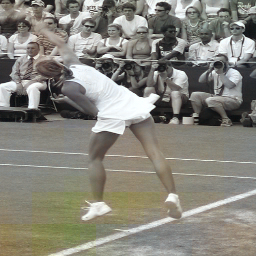

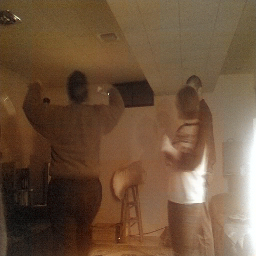

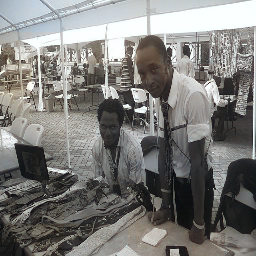

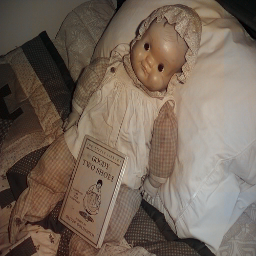

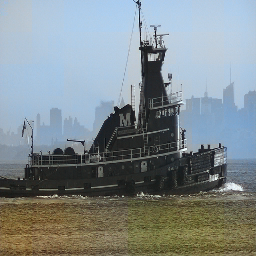

In [37]:
from IPython.display import Image, display

for i in range(1,6):
    display(Image(f"/kaggle/working/output_{i}.png"))

In [38]:
%%writefile /kaggle/working/train.py
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from dataset import ColorizationDataset
from model import ResNetUNet
from perceptual import VGGPerceptualLoss

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

dataset_path = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017"

# 🔥 Increased dataset size
dataset = ColorizationDataset(dataset_path, max_images=30000)
loader = DataLoader(dataset, batch_size=16, shuffle=True, num_workers=2)

model = ResNetUNet().to(device)

l1_loss = nn.L1Loss()
perc_loss = VGGPerceptualLoss().to(device)

# 🔥 Lower learning rate for stable long training
optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)

epochs = 25

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for L, ab in loader:
        L = L.to(device)
        ab = ab.to(device)

        optimizer.zero_grad()
        output = model(L)

        loss_l1 = l1_loss(output, ab)
        loss_perc = perc_loss(output, ab)

        loss = loss_l1 + 0.2 * loss_perc

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {total_loss/len(loader):.4f}")

torch.save(model.state_dict(), "/kaggle/working/colorization_model.pth")
print("Model saved.")

Overwriting /kaggle/working/train.py


In [39]:
!python /kaggle/working/train.py

Using device: cuda
Epoch [1/25] Loss: 0.1291
Epoch [2/25] Loss: 0.1178
Epoch [3/25] Loss: 0.1151
Epoch [4/25] Loss: 0.1134
Epoch [5/25] Loss: 0.1123
Epoch [6/25] Loss: 0.1109
Epoch [7/25] Loss: 0.1093
Epoch [8/25] Loss: 0.1076
Epoch [9/25] Loss: 0.1056
Epoch [10/25] Loss: 0.1037
Epoch [11/25] Loss: 0.1020
Epoch [12/25] Loss: 0.1005
Epoch [13/25] Loss: 0.0991
Epoch [14/25] Loss: 0.0977
Epoch [15/25] Loss: 0.0964
Epoch [16/25] Loss: 0.0953
Epoch [17/25] Loss: 0.0942
Epoch [18/25] Loss: 0.0932
Epoch [19/25] Loss: 0.0923
Epoch [20/25] Loss: 0.0914
Epoch [21/25] Loss: 0.0905
Epoch [22/25] Loss: 0.0898
Epoch [23/25] Loss: 0.0891
Epoch [24/25] Loss: 0.0884
Epoch [25/25] Loss: 0.0876
Model saved.


In [48]:
!python /kaggle/working/colorize.py

Selected Images: ['000000500826.jpg', '000000217948.jpg', '000000348708.jpg', '000000294695.jpg', '000000007088.jpg']
Saved /kaggle/working/output_1.png
Saved /kaggle/working/output_2.png
Saved /kaggle/working/output_3.png
Saved /kaggle/working/output_4.png
Saved /kaggle/working/output_5.png


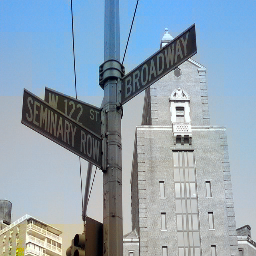

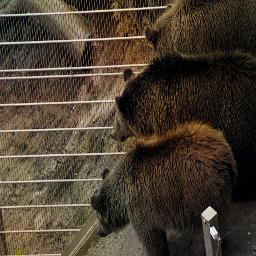

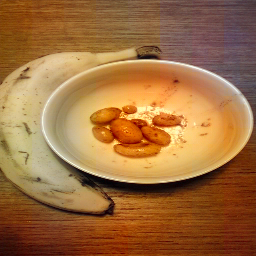

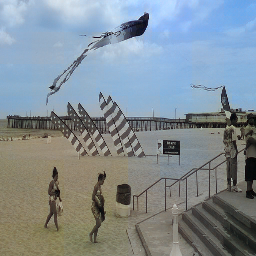

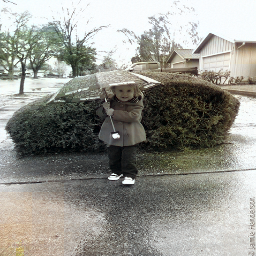

In [49]:
from IPython.display import Image, display

for i in range(1,6):
    display(Image(f"/kaggle/working/output_{i}.png"))